# Majoranic chemistry simulations

This notebook demonstrates how to simulate a quantum circuit (expressed in Majoranas) using the monoprop package.

## Background
The Majorana propagation can efficiently simulate fermionic systems without mapping to qubits, allowing larger system sizes and higher accuracy through controlled truncation of the operator algebra.

Two variants are explored below:
- **Schrödinger picture** – the state is propagated forward.
- **Heisenberg picture** – the Hamiltonian is propagated backward (time-reversed).

## 1. Imports and Environment

The cell below imports all required packages and sets two environment variables that control `monoprop` behaviour before anything else is loaded:

In [1]:
from __future__ import annotations

import numpy as np
from pyscf import ao2mo, gto, mcscf, scf

from monoprop import MonomialPropagator
from monoprop.fermi_data import FermiEvGate, FermiGatesSequence, MajoranaOperator
from monoprop.integral_conversion import integrals_to_fermion

## 2. The chemistry setup

We will use as a toy model the popular chromium dimer, a famous case of strongly correlated molecule. Here we will use pyscf to obtain the integrals though in principle any tool can be used. We choose an active space of 12 electrons in 12 orbitals, representing all 3d and 4s orbitals of the chromium atoms.

In [2]:
# Define the molecule (Cr2 at 1.65 Å)
mol = gto.M(
    atom="""
    Cr 0.0 0.0 0.0
    Cr 0.0 0.0 1.65
    """,
    basis="def2-svp",
    spin=0,  # singlet
)

# Hartree-Fock
mf = scf.RHF(mol)
mf.kernel()

# --------------------------------------------------
# Choose active orbitals from canonical HF orbitals
# (indices are 0-based)
# --------------------------------------------------

cas_list = [18, 19, 20, 21, 22, 23, 24, 25, 26, 31, 32, 33]

mc = mcscf.CASCI(mf, 12, 12)
mo_ord = mc.sort_mo(cas_list, base=0)
mc.mo_coeff = mo_ord

# CASCI to use as reference expectation value (impractical for active spaces > 16 orbitals)

ref_energy, *_ = mc.kernel()

converged SCF energy = -2085.59838679633
CASCI E = -2086.12157627045  E(CI) = -31.4497234166793  S^2 = 0.0000002


In [3]:
# Retrieve integrals
h1e, ecore = mc.get_h1eff()
g2e = mc.get_h2eff()
g2e = ao2mo.restore(1, g2e, 12)

# Convert to unrestricted format
h1 = np.array([h1e, h1e])
g2 = np.array([g2e, g2e, 0.5 * (g2e + g2e.transpose(2, 3, 0, 1))])

# Transform to Fermionic Operator
hamiltonian = integrals_to_fermion([ecore, h1, g2])

n_modes = 2 * len(cas_list)  # number of spin-orbitals
hf = [
    0,
    1,
    2,
    3,
    4,
    5,
    12,
    13,
    14,
    15,
    16,
    17,
]  # occupation in the Hartree-Fock state (the first 6 alpha and 6 beta orbitals)

## 3. Monoprop simulations
### Helper Functions
**`plot_energies`** – plots $|E_k - E_\text{FCI}|$ on a log scale against circuit gate.

In [4]:
def plot_energies(energies: list[float], ref_energy: float | None = None) -> None:
    import matplotlib.pyplot as plt

    if ref_energy is None or ref_energy == 0:
        ref_energy = min(energies)
    diff = np.abs(np.array(energies) - ref_energy)
    plt.plot(diff, marker="o")
    plt.yscale("log")
    plt.xlabel("Gate")
    plt.ylabel("Energy - Ground State Energy")
    plt.title("Energy convergence in Monoprop")
    plt.grid()
    plt.show()

### The Majorana circuit
Here we will use a 10 gates circuit, i.e. a circuit containing 10 Majorana operators $\hat{M}_j$ (that are related to excitation operators) to add correlation. The expectation value or any other properties can then be evaluated as

$$ E = \langle \Psi_\mathrm{HF} | \hat{U}^\dagger \hat{H} \hat{U} | \Psi_\mathrm{HF} \rangle $$

with
$$\hat{U} = \prod_{j=0}^{10} e^{-i\theta_j \hat{M}_j}$$

In monoprop, this can be done by either applying the Majorana operators on the state (Schrödinger picture) or on the operator (Heisenberg picture). The choice of Majorana operator $M_j$ and angle $\theta_j$ can be done iteratively through an ADAPT procedure. Here we just used a pre-optimized circuit.

In [5]:
gates = [
    (6, 9, 15, 17),
    (30, 33, 39, 41),
    (4, 23, 29, 47),
    (0, 21, 25, 45),
    (2, 19, 27, 43),
    (26, 43, 5, 23),
    (3, 4, 18, 22),
    (28, 47, 1, 21),
    (24, 45, 5, 23),
    (1, 4, 20, 22),
]
angles = [
    -0.5506,
    -0.5506,
    0.1842,
    0.1391,
    0.1481,
    0.1369,
    0.1286,
    0.1318,
    0.1361,
    0.1002,
]

circuit = [
    FermiEvGate(generator=MajoranaOperator([gate], [1.0], n_modes), parameter=angle)
    for gate, angle in zip(gates, angles)
]

### Schrödinger Picture

In the **Schrödinger picture** the ansatz acts on the initial state. The simulator propagates the *state* forward through the ansatz layers.

**Key parameters for this run:**

| Parameter | Value | Meaning |
|---|---|---|
| `cutoff` | 6 | Maximum Majorana-string length kept in the Hamiltonian |
| `schrodinger_cutoff` | `cutoff + 2` | Maximum string length in the propagated state — set slightly larger than `cutoff` to capture leading corrections |

The initial expectation value (before any gates added) gives the Hartree-Fock expectation value within the truncation.

In [6]:
# First, we set the cutoffs for the simulation. The `cutoff` parameter determines
# the maximum length of the Majorana strings that will be included in the simulation, while the `schrodinger_cutoff`
# parameter determines the maximum length of the Majorana strings that will be included in the
# initial state.
cutoff = 6
schrodinger_cutoff = cutoff + 2

quantum_circuit = FermiGatesSequence(gates=circuit)

simulator = MonomialPropagator(
    hamiltonian, hf, cutoff, schrodinger_cutoff=schrodinger_cutoff
)

initial_expval = simulator.expectation_value(ignore_coeffs=True)
print(f"Initial energy: {initial_expval:.4f} (diff: {initial_expval - ref_energy:.4f})")

Initial energy: -2085.5984 (diff: 0.5232)


We can now evolve the state using the gates one by one to see the successive improvement in the expectation value.

Energy after gate 1: -2085.7107 (diff: 0.4109)
Energy after gate 2: -2085.8220 (diff: 0.2996)
Energy after gate 3: -2085.8641 (diff: 0.2575)
Energy after gate 4: -2085.8850 (diff: 0.2365)
Energy after gate 5: -2085.9066 (diff: 0.2150)
Energy after gate 6: -2085.9180 (diff: 0.2036)
Energy after gate 7: -2085.9297 (diff: 0.1919)
Energy after gate 8: -2085.8992 (diff: 0.2224)
Energy after gate 9: -2085.8642 (diff: 0.2574)
Energy after gate 10: -2085.8408 (diff: 0.2808)


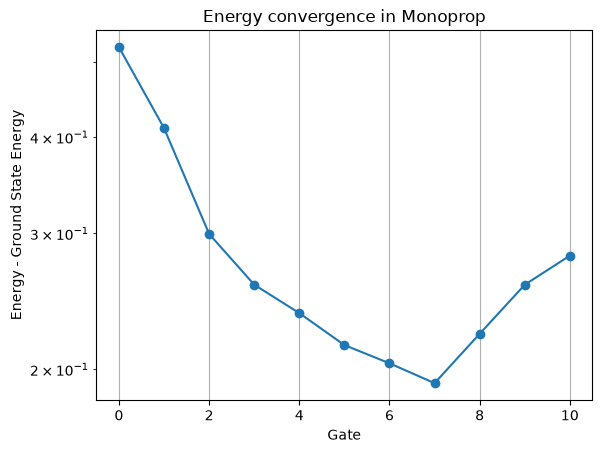

In [ ]:
expvals_schrodinger = [initial_expval]
for i in range(10):
    simulator.propagate(
        FermiGatesSequence(gates=[circuit[i]]), ignore_circuit_parameters=False
    )
    simulator_expval = simulator.expectation_value(ignore_coeffs=True)
    print(
        f"Energy after gate {i + 1:1d}: {simulator_expval:.4f} (diff: {simulator_expval - ref_energy:.4f})"
    )
    expvals_schrodinger.append(simulator_expval)
plot_energies(expvals_schrodinger, ref_energy)

### Heisenberg Picture

In the **Heisenberg picture**, the roles of state and operator are swapped: instead of propagating the state forward, we propagate the Hamiltonian backward through the ansatz:

$$\hat{H}(\boldsymbol{\theta}) = e^{-\theta_1 \hat{A}_{n_1}} \cdots e^{-\theta_k \hat{A}_{n_k}}\, \hat{H}\, e^{\theta_k \hat{A}_{n_k}} \cdots e^{\theta_1 \hat{A}_{n_1}}$$

The expectation value is then evaluated as $E = \langle \Phi_\text{HF} | \hat{H}(\boldsymbol{\theta}) | \Phi_\text{HF} \rangle$.

**Advantages over the Schrödinger picture:**
- The operator algebra stays within the truncated Majorana space without a growing state vector.
- A larger `cutoff` can typically be used, capturing more correlations.
- Memory scaling is generally more favourable for deeper ansätze.

Initial energy: -2085.5984 (diff: 0.5232)
Energy after gate 0: -2085.5984 (diff: 0.5232)
Energy after gate 1: -2085.7107 (diff: 0.4109)
Energy after gate 2: -2085.8220 (diff: 0.2996)
Energy after gate 3: -2085.8641 (diff: 0.2575)
Energy after gate 4: -2085.8850 (diff: 0.2365)
Energy after gate 5: -2085.9066 (diff: 0.2150)
Energy after gate 6: -2085.9180 (diff: 0.2036)
Energy after gate 7: -2085.9302 (diff: 0.1914)
Energy after gate 8: -2085.8997 (diff: 0.2218)
Energy after gate 9: -2085.8643 (diff: 0.2573)
Energy after gate 10: -2085.8417 (diff: 0.2799)


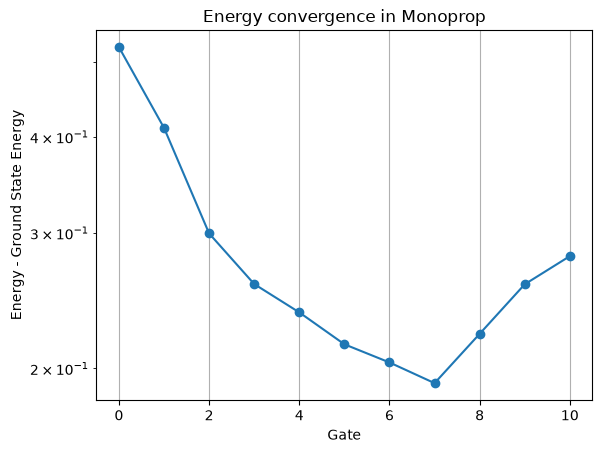

In [ ]:
# Heisenberg picture: schrodinger_cutoff=None tells the simulator to propagate
# the Hamiltonian operator rather than the state. A larger cutoff is viable here
# because the operator space does not grow with ansatz depth.
cutoff = 10
schrodinger_cutoff = None

simulator = MonomialPropagator(hamiltonian, hf, cutoff)

initial_expval = simulator.expectation_value(ignore_coeffs=True)
print(f"Initial energy: {initial_expval:.4f} (diff: {initial_expval - ref_energy:.4f})")

energies_heisenberg = []
for i in range(11):
    simulator = MonomialPropagator(hamiltonian, hf, cutoff)
    simulator.propagate(
        FermiGatesSequence(gates=circuit[:i]), ignore_circuit_parameters=False
    )
    simulator_expval = simulator.expectation_value(ignore_coeffs=True)
    print(
        f"Energy after gate {i:1d}: {simulator_expval:.4f} (diff: {simulator_expval - ref_energy:.4f})"
    )
    energies_heisenberg.append(simulator_expval)
plot_energies(energies_heisenberg, ref_energy)

### Comparison: Schrödinger vs Heisenberg

Both runs used the same circuits, but with different cutoffs and propagation strategies. The plot below overlays their convergence curves on a single log-scale axis so the trade-off is immediately visible.

Note that the two runs are not apples-to-apples: the Heisenberg picture uses a larger `cutoff` (10 vs 6), which generally yields a better starting expectation value and faster convergence per iteration at the cost of more compute per expectation value evaluation.

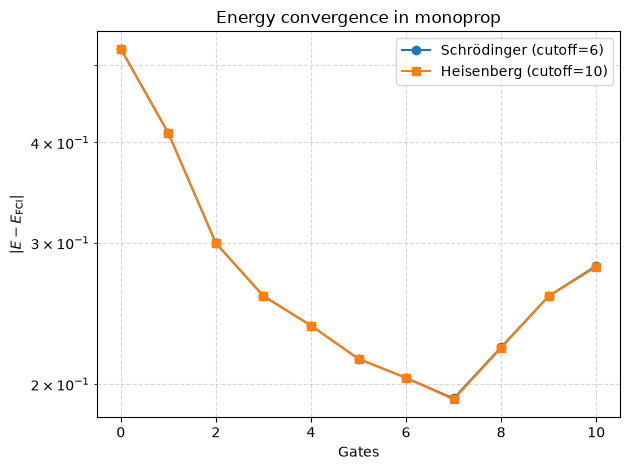

In [9]:
import matplotlib.pyplot as plt

diff_s = np.abs(np.array(expvals_schrodinger) - ref_energy)
diff_h = np.abs(np.array(energies_heisenberg) - ref_energy)

fig, ax = plt.subplots()
ax.plot(diff_s, marker="o", label=f"Schrödinger (cutoff={6})")
ax.plot(diff_h, marker="s", label=f"Heisenberg (cutoff={10})")
ax.set_yscale("log")
ax.set_xlabel("Gates")
ax.set_ylabel(r"$|E - E_\mathrm{FCI}|$")
ax.set_title("Energy convergence in monoprop")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Summary and Next Steps

This notebook demonstrated Majorana simulations on a 12-electron/12-orbital molecular active space.

**Things to try:**
- Vary `cutoff` and `schrodinger_cutoff` to study the accuracy/cost trade-off.
- Try different properties ($S^2$, natural orbitals)